#Question 2 - Principles of Data Science CS5530
##Morgan Sansone

**Summary**
1) Take a random sample of 25 observations (seed for reproducibility), compare the sample's mean and max Glucose to the population's

2) Find 98th percentile of BMI for the sample and the pop

3) Bootstrap 500 samples of 150 observations each then compare the average bootstrap mean, standard deviation, and percentile of BloodPressure with the pop values


### Import Libraries & Add Data to DF

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('https://raw.githubusercontent.com/morgansansone/Principles-of-DS-CS5530/refs/heads/main/Assignment2_3/Question2/raw_data/diabetes.csv') # population data
print(df.shape)
df.head(5)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


###1) Sample of 25

In [48]:
sample25 = df.sample(n=25, random_state=42) # random sample 25

# sample stats
sample_mean = sample25['Glucose'].mean()
sample_max = sample25['Glucose'].max()

# population stats
pop_mean = df['Glucose'].mean()
pop_max = df['Glucose'].max()

print(f'Sample mean Glucose: {sample_mean:.2f}')
print(f'Population mean Glucose: {pop_mean:.2f}\n')
print(f'Sample max Glucose: {sample_max}')
print(f'Population max Glucose: {pop_max}')

Sample mean Glucose: 116.64
Population mean Glucose: 120.89

Sample max Glucose: 183
Population max Glucose: 199


<Figure size 2400x1800 with 0 Axes>

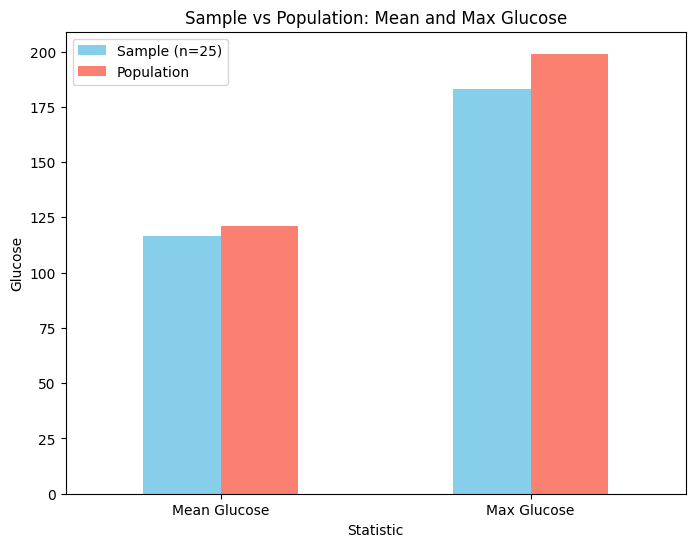

In [49]:
# bar chart comparing sample vs population
plt.figure(figsize=(8, 6), dpi=300)

compare = pd.DataFrame({'Sample (n=25)': [sample_mean, sample_max],
                        'Population': [pop_mean, pop_max]},
                       index=['Mean Glucose', 'Max Glucose'])

compare.plot.bar(figsize=(8, 6), color=['skyblue', 'salmon'], rot=0)

plt.title('Sample vs Population: Mean and Max Glucose')
plt.xlabel('Statistic')
plt.ylabel('Glucose')

plt.savefig('q1_glucose_compare.png', dpi=300)
plt.show()

The sample mean and max Glucose are very close to the population values. I think this makes sense because the sample was random. Sample max is less than the population max which is normal. Having a different seed would shift the sample mean up or down a bit.

###2) 98th percentile of BMI

In [50]:
sample_p98 = np.percentile(sample25['BMI'], 98)
pop_p98 = np.percentile(df['BMI'], 98)

print(f'Sample 98th percentile BMI: {sample_p98:.2f}')
print(f'Population 98th percentile BMI: {pop_p98:.2f}')

Sample 98th percentile BMI: 40.25
Population 98th percentile BMI: 47.53


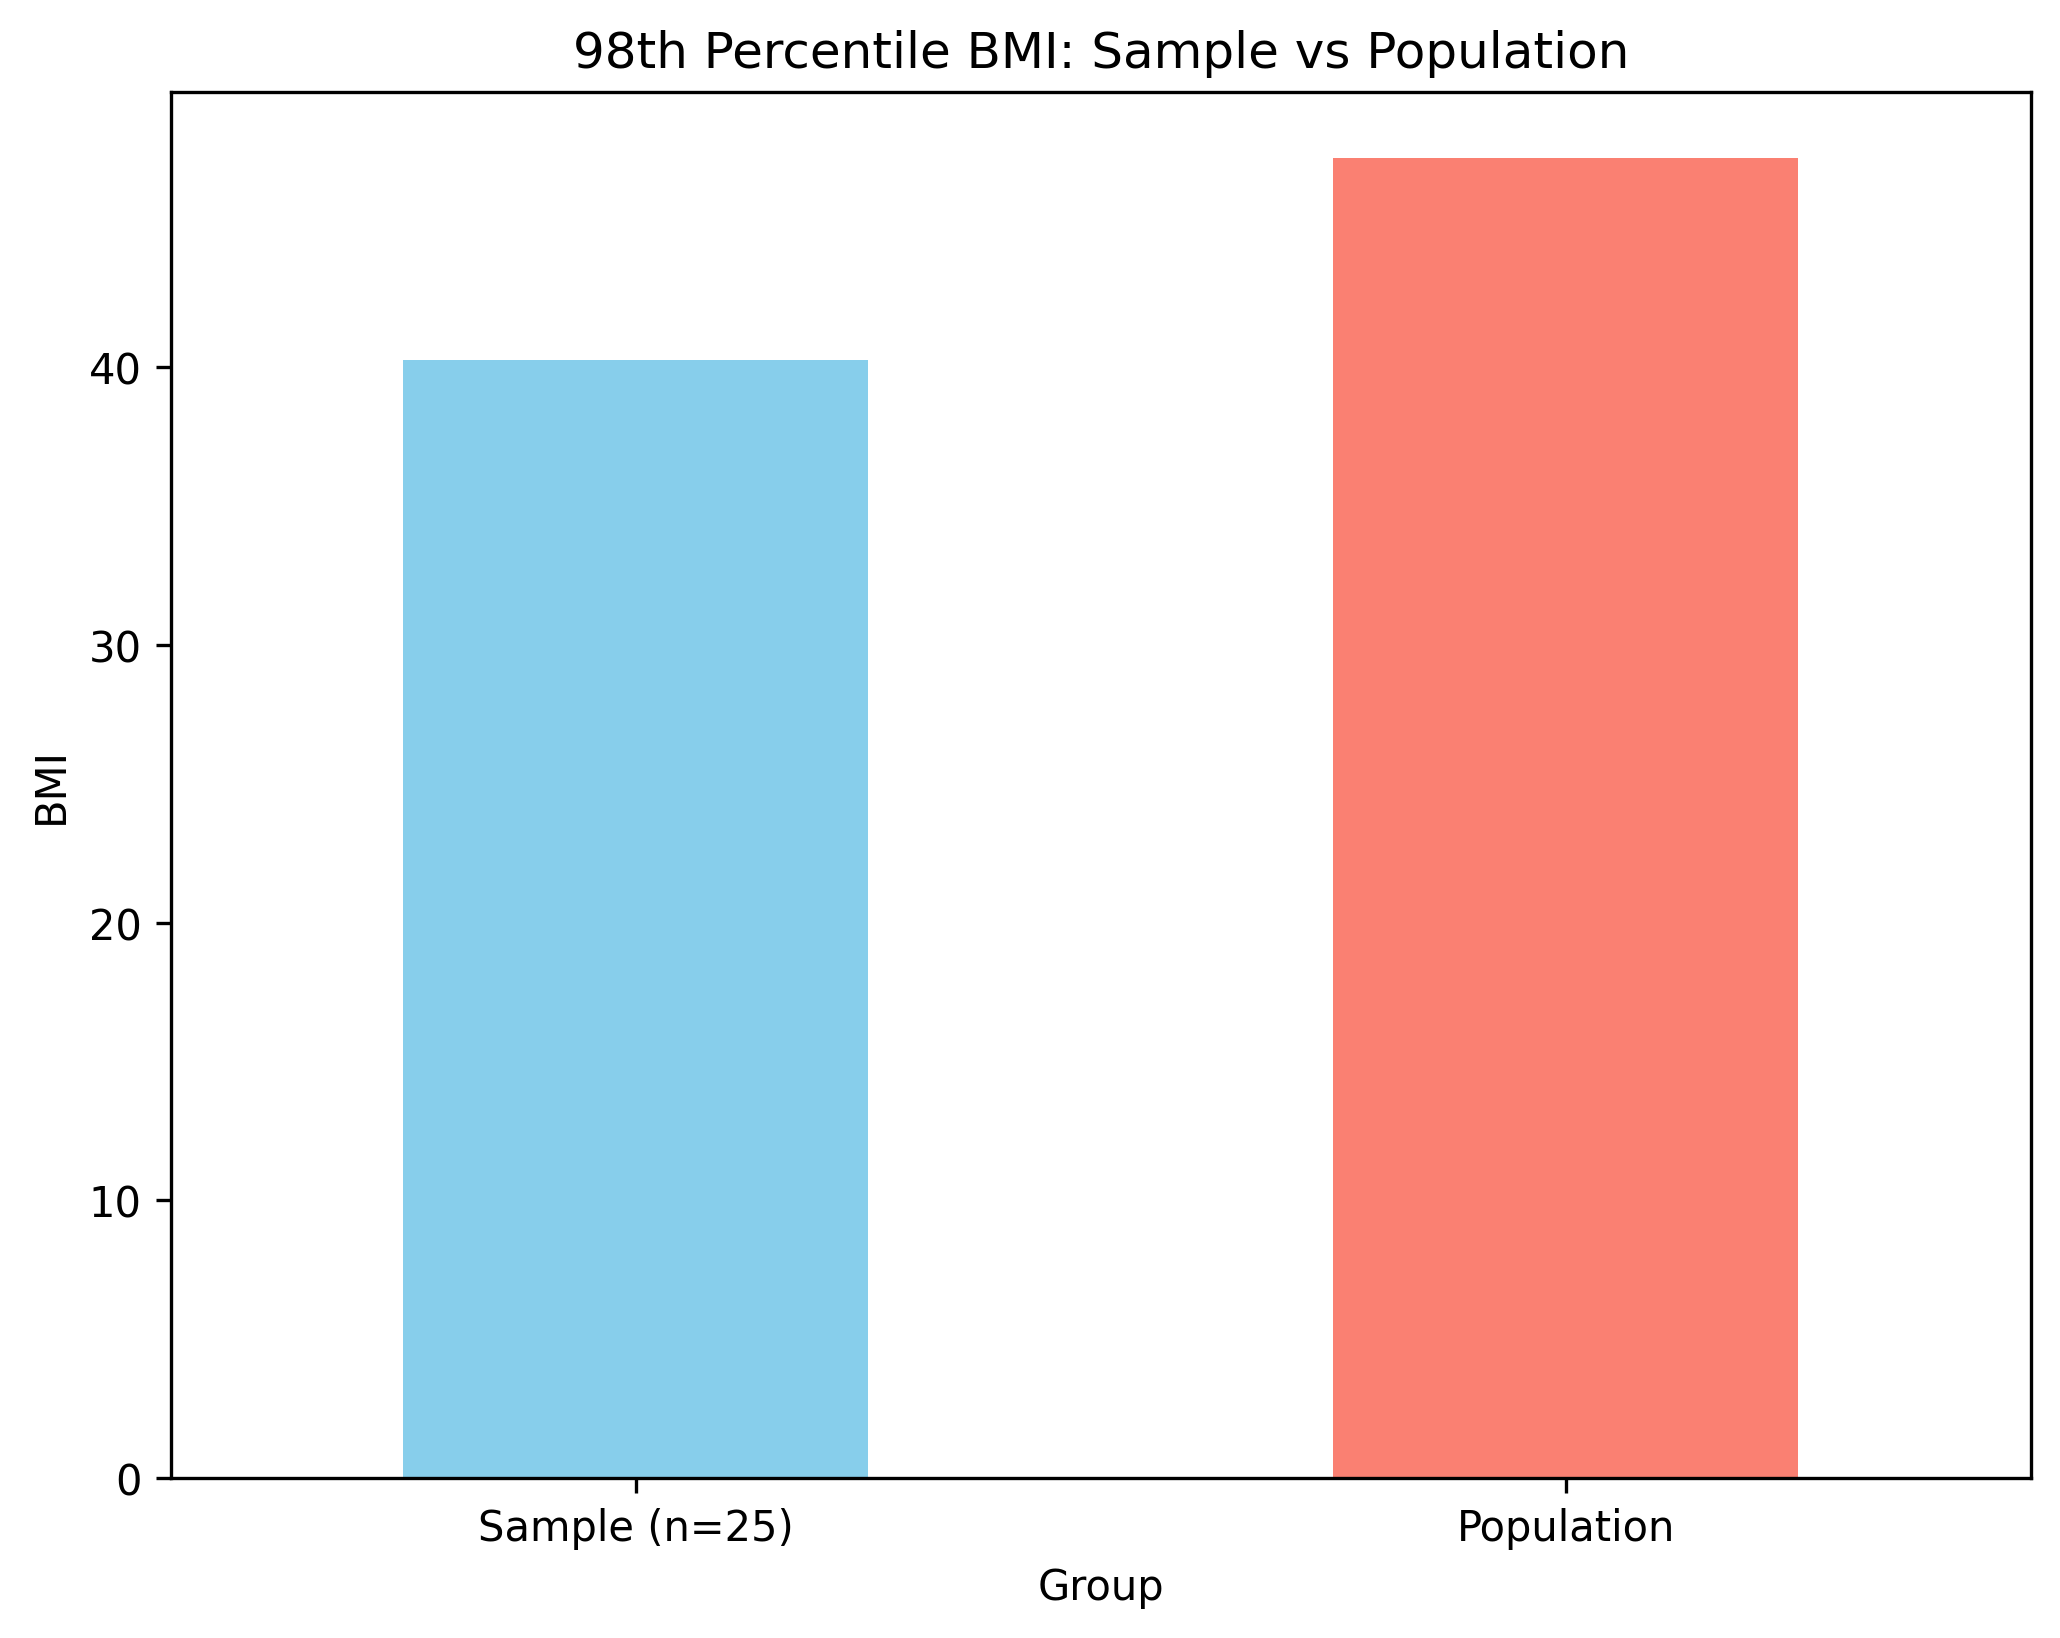

In [51]:
# bar chart comparing the 98th percentile BMI
plt.figure(figsize=(8, 6), dpi=300)

compare_bmi = pd.Series({'Sample (n=25)': sample_p98,
                         'Population':    pop_p98})

compare_bmi.plot.bar(figsize=(8, 6), color=['skyblue', 'salmon'], rot=0)

plt.title('98th Percentile BMI: Sample vs Population')
plt.xlabel('Group')
plt.ylabel('BMI')

plt.savefig('q2_bmi_p98_compare.png', dpi=300)
plt.show()

Having the percent is more valuable when the sample is smaller, theres only 25 observations so the 98th percentile will get the max of the sample and it depends on what values the random seed drew out. The population is more stable because its based on lots of observations.

###3) Bootstrap

In [52]:
np.random.seed(42) # seed for reproducibility

n_bootstraps = 500
sample_size = 150

boot_means = []
boot_stds = []
boot_p95s = []

for _ in range(n_bootstraps):
    bs = df['BloodPressure'].sample(n=sample_size, replace=True)
    boot_means.append(bs.mean())
    boot_stds.append(bs.std())
    boot_p95s.append(np.percentile(bs, 95)) # 95th percentile

# average of each bootstrap statistic
avg_boot_mean = np.mean(boot_means)
avg_boot_std = np.mean(boot_stds)
avg_boot_p95 = np.mean(boot_p95s)

# population statistics for comparison
pop_bp_mean = df['BloodPressure'].mean()
pop_bp_std = df['BloodPressure'].std()
pop_bp_p95 = np.percentile(df['BloodPressure'], 95)

print(f'Bootstrap avg mean: {avg_boot_mean:.2f}')
print(f'Population mean: {pop_bp_mean:.2f}\n')
print(f'Bootstrap avg std: {avg_boot_std:.2f}')
print(f'Population std: {pop_bp_std:.2f}\n')
print(f'Bootstrap avg 95th pct: {avg_boot_p95:.2f}')
print(f'Population 95th pct: {pop_bp_p95:.2f}')

Bootstrap avg mean: 69.18
Population mean: 69.11

Bootstrap avg std: 19.07
Population std: 19.36

Bootstrap avg 95th pct: 91.13
Population 95th pct: 90.00


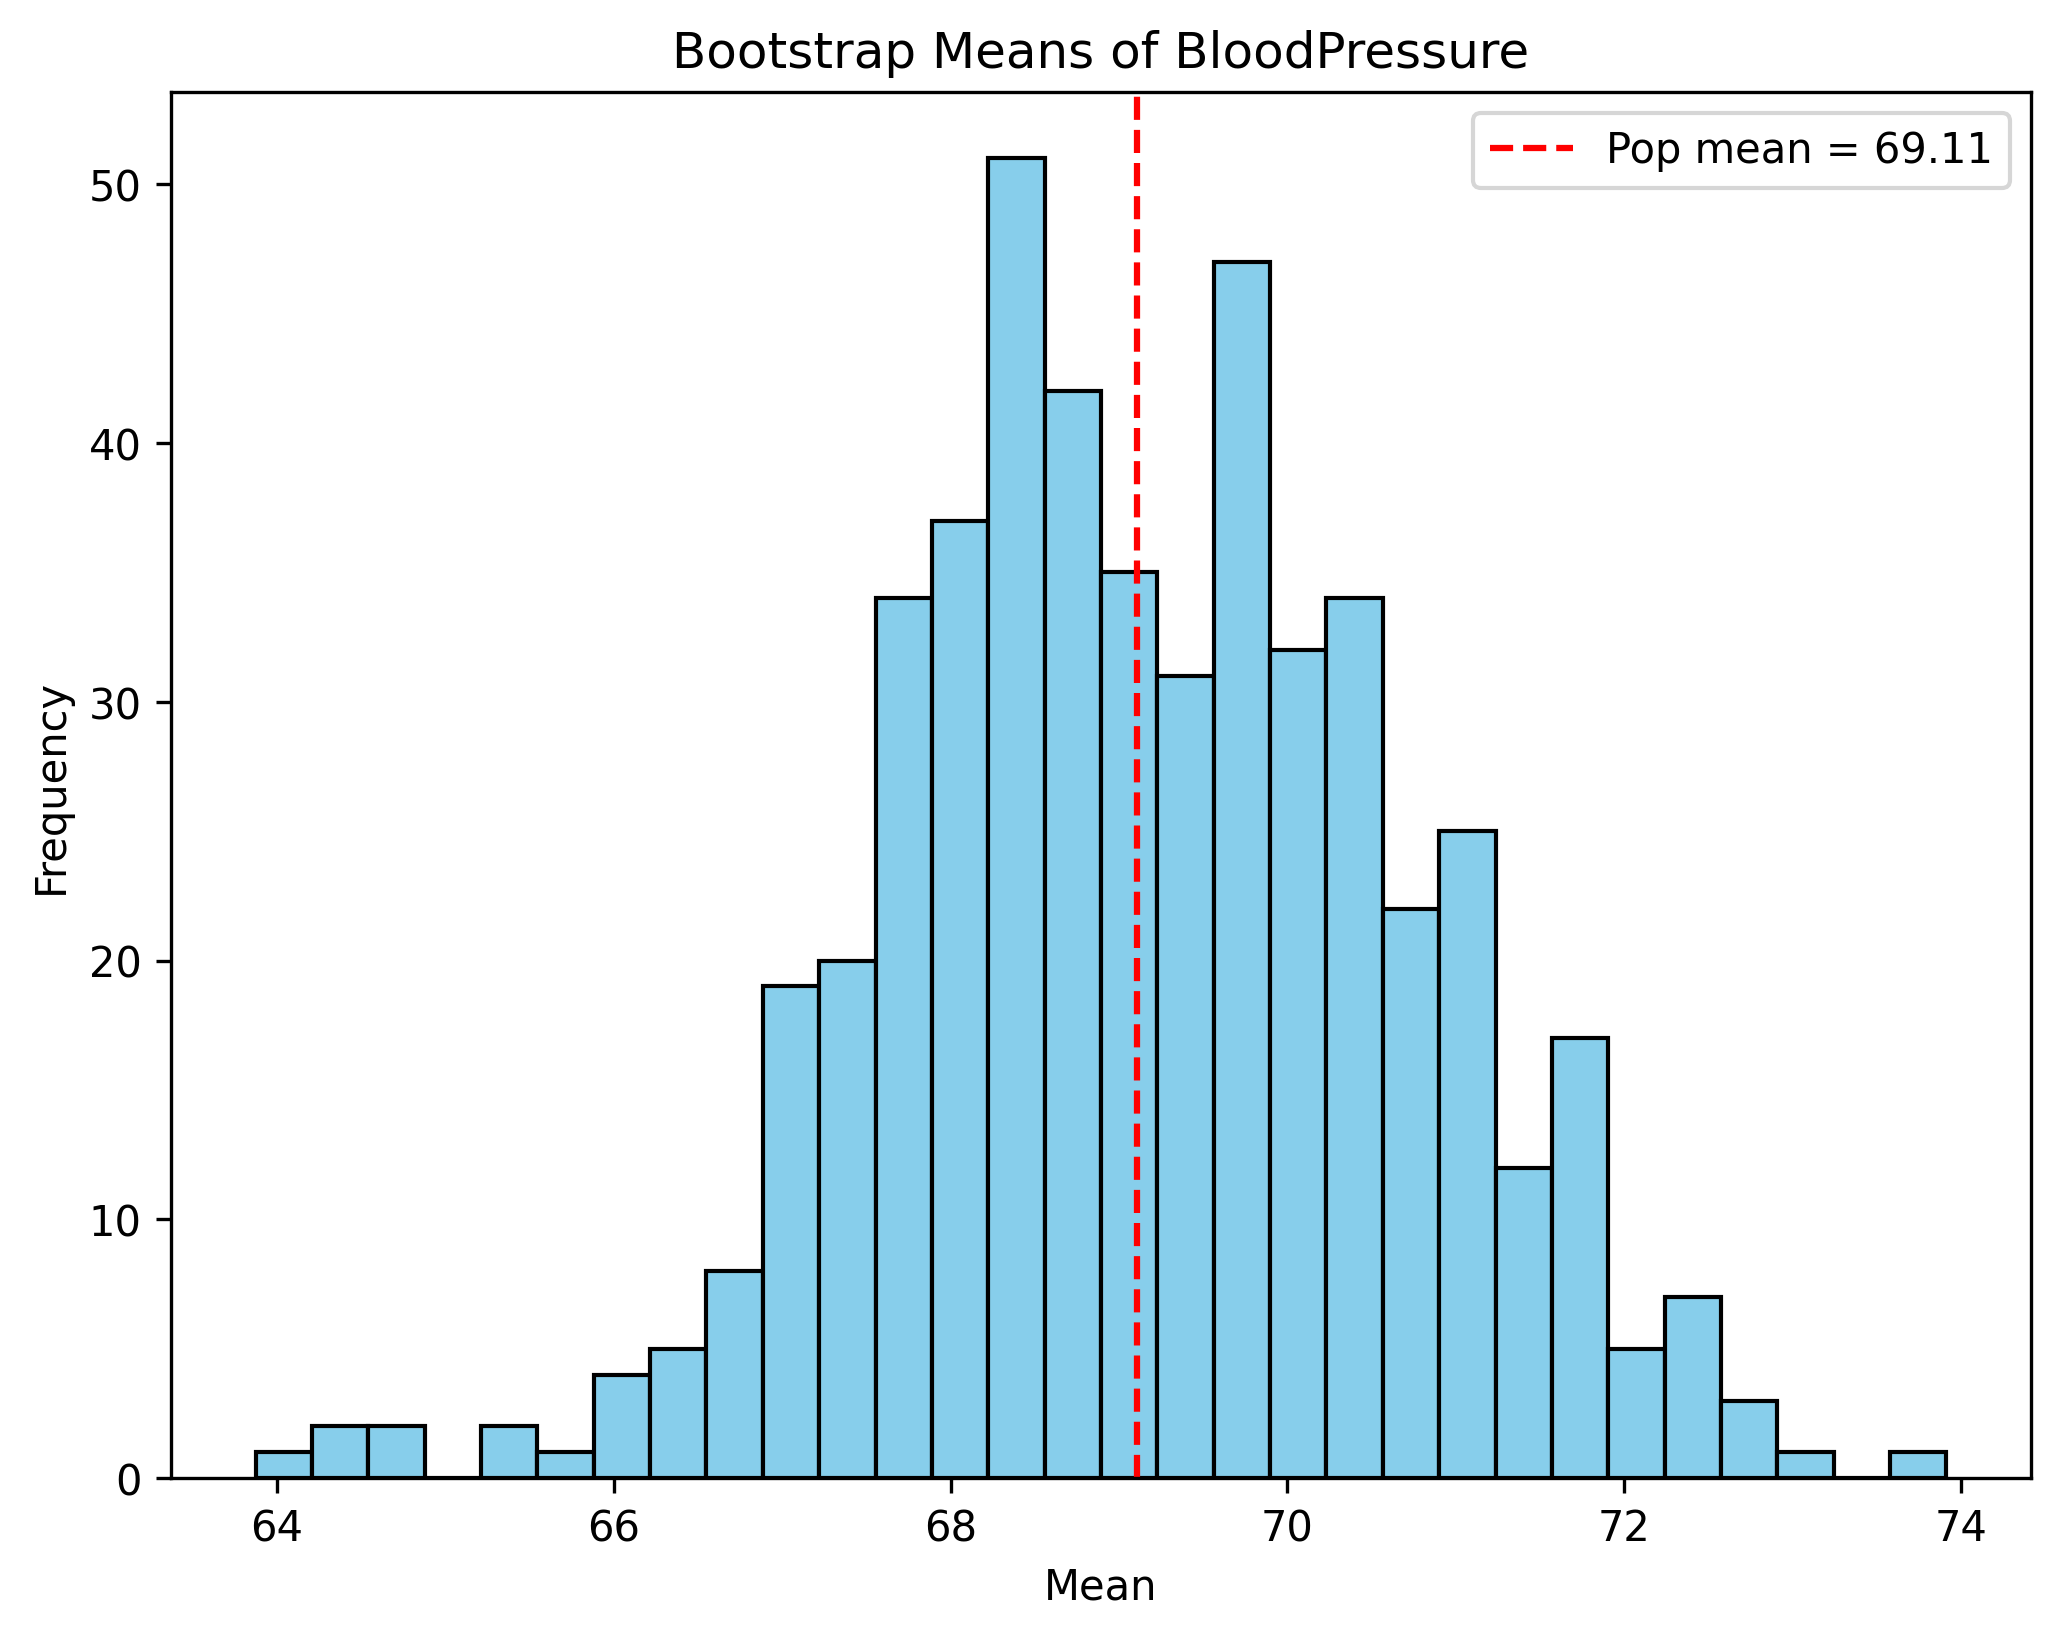

In [54]:
# histograms of bootstrap means
plt.figure(figsize=(8, 6), dpi=300)

plt.hist(boot_means, bins=30, color='skyblue', edgecolor='black')
plt.axvline(pop_bp_mean, color='red', linestyle='--', label=f'Pop mean = {pop_bp_mean:.2f}')

plt.title('Bootstrap Means of BloodPressure')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('q3_boot_means.png', dpi=300)
plt.show()

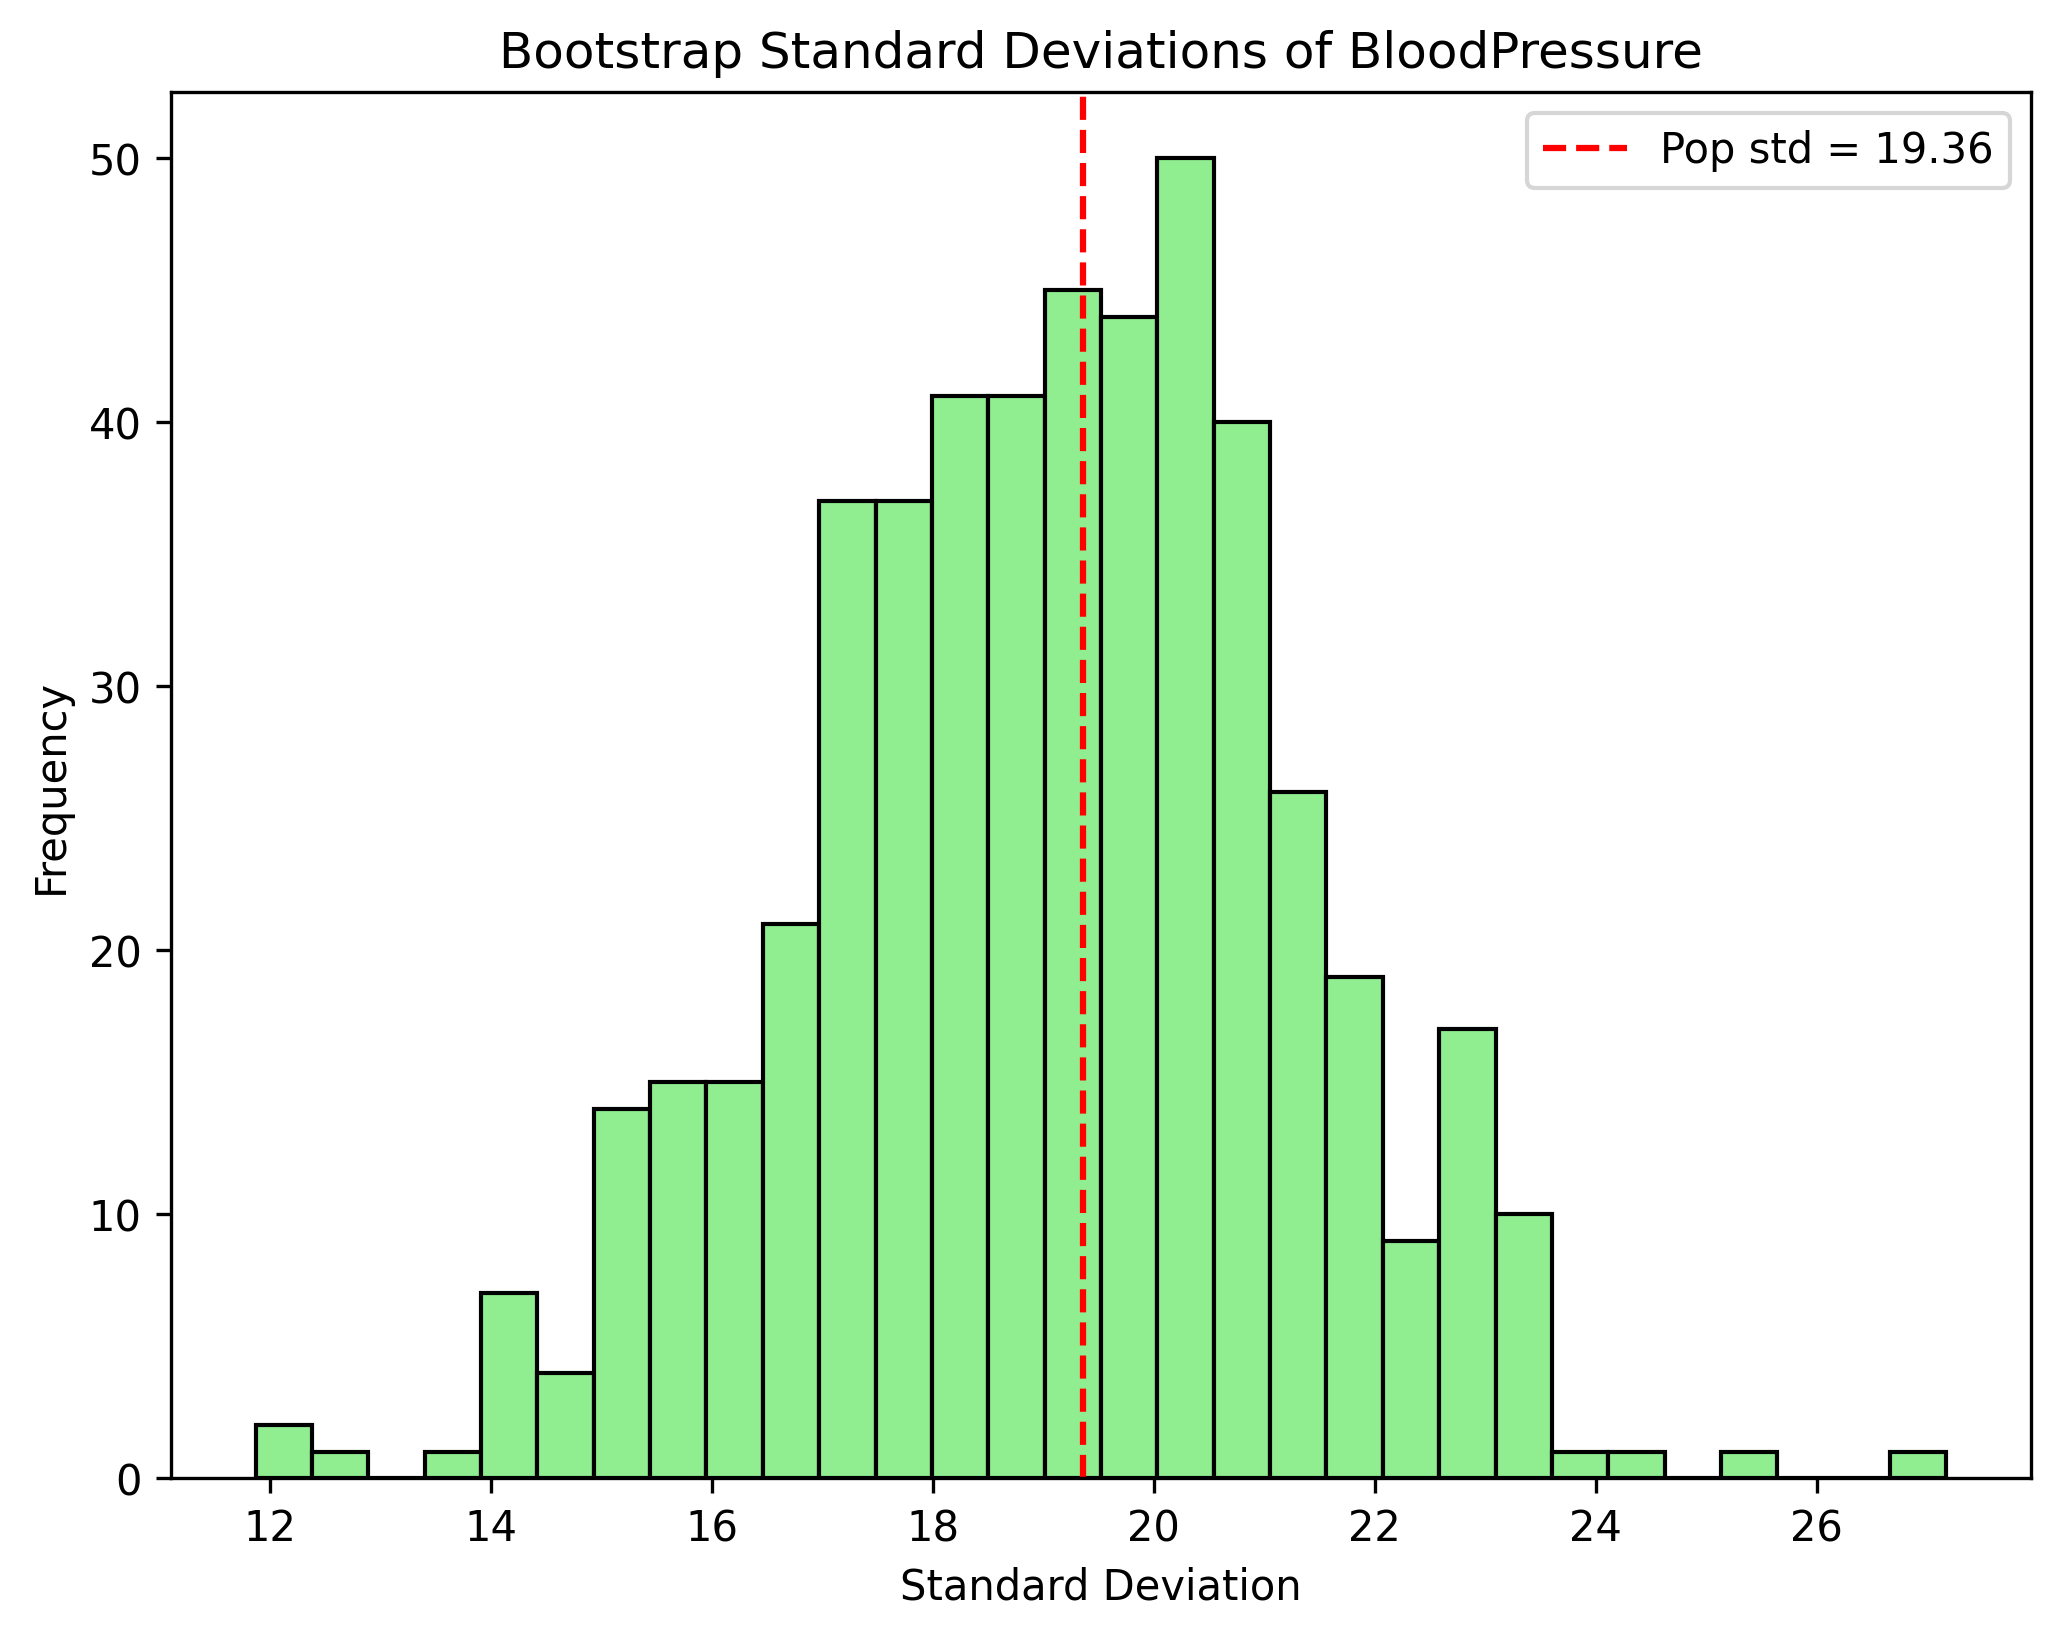

In [55]:
# histogram of bootstrap std devs
plt.figure(figsize=(8, 6), dpi=300)

plt.hist(boot_stds, bins=30, color='lightgreen', edgecolor='black')
plt.axvline(pop_bp_std, color='red', linestyle='--', label=f'Pop std = {pop_bp_std:.2f}')

plt.title('Bootstrap Standard Deviations of BloodPressure')
plt.xlabel('Standard Deviation')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('q3_boot_stds.png', dpi=300)
plt.show()

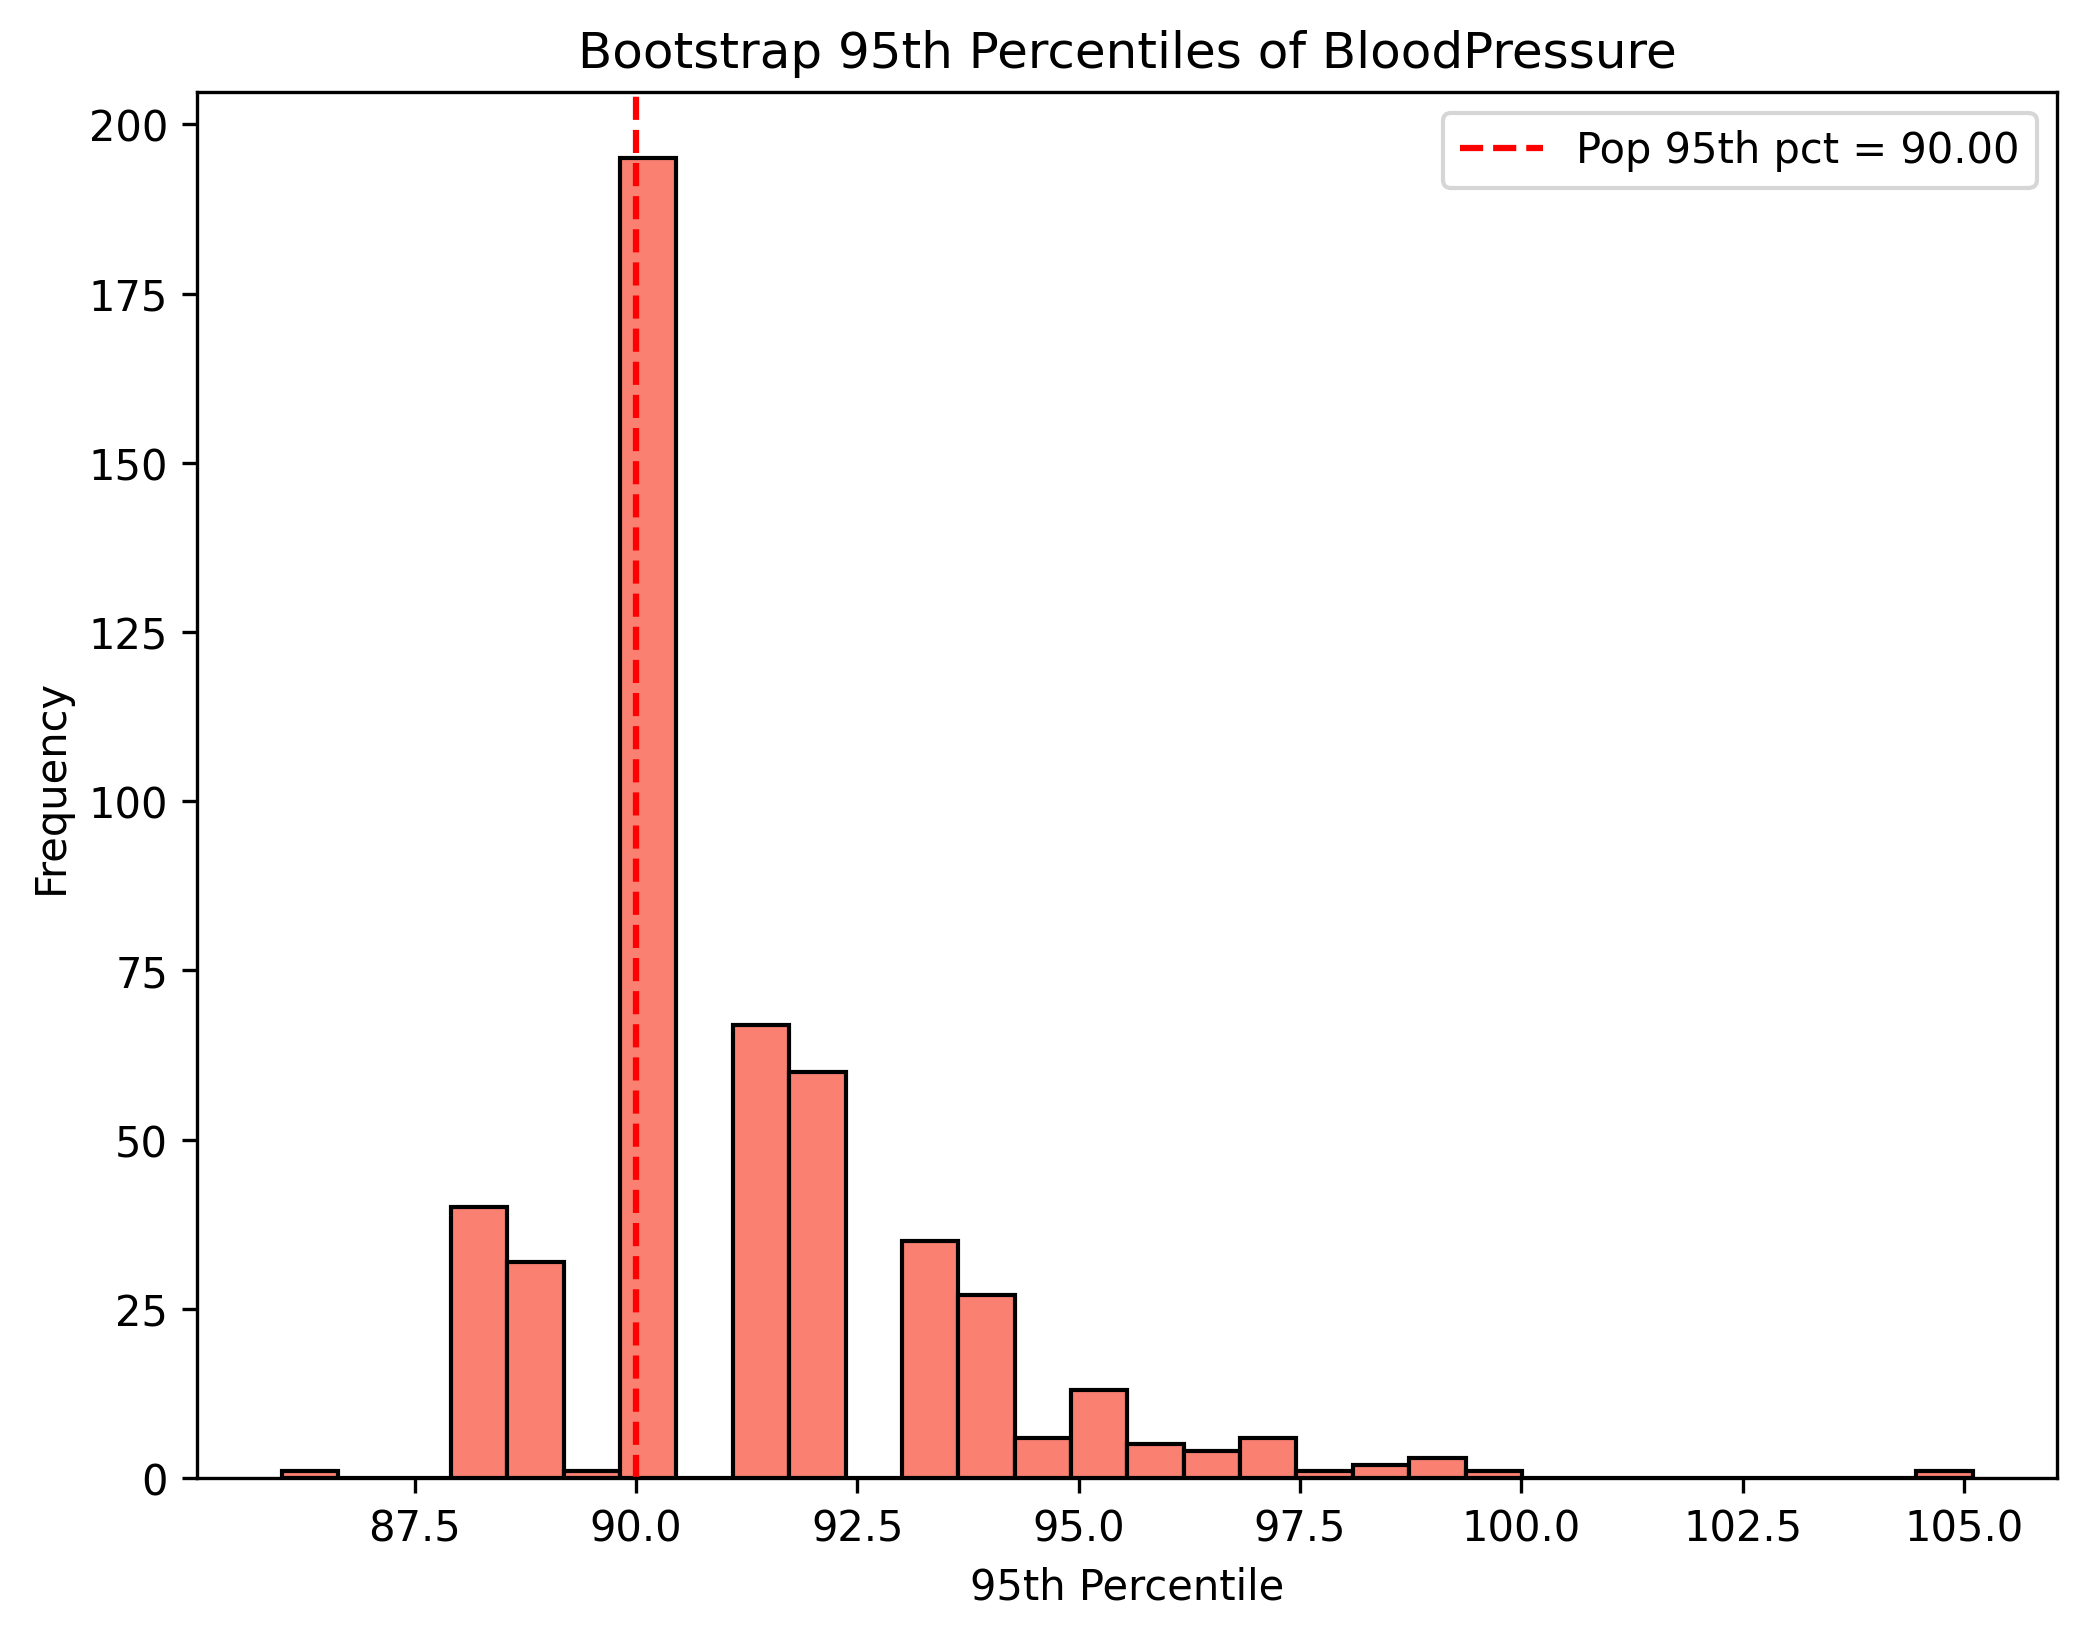

In [56]:
# histogram of bootstrap 95th percentiles
plt.figure(figsize=(8, 6), dpi=300)

plt.hist(boot_p95s, bins=30, color='salmon', edgecolor='black')
plt.axvline(pop_bp_p95, color='red', linestyle='--', label=f'Pop 95th pct = {pop_bp_p95:.2f}')

plt.title('Bootstrap 95th Percentiles of BloodPressure')
plt.xlabel('95th Percentile')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('q3_boot_p95s.png', dpi=300)
plt.show()

<Figure size 2400x1800 with 0 Axes>

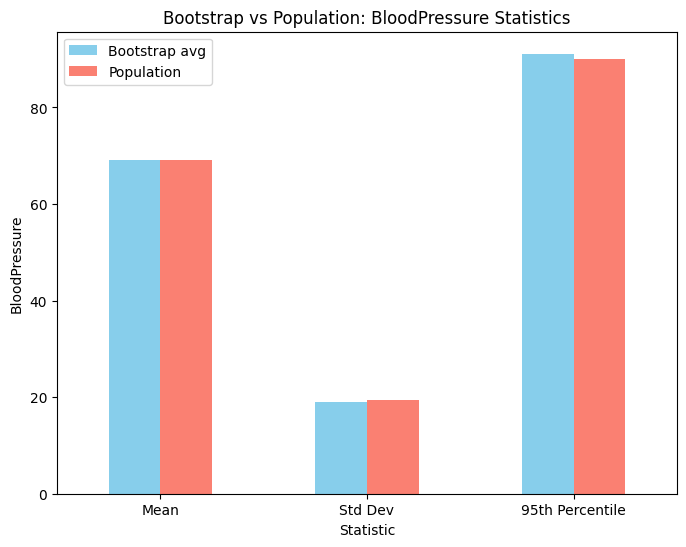

In [57]:
# bar chart of bootstrap avg vs population for the three stats
plt.figure(figsize=(8, 6), dpi=300)

compare_bp = pd.DataFrame({'Bootstrap avg': [avg_boot_mean, avg_boot_std, avg_boot_p95],
                           'Population': [pop_bp_mean, pop_bp_std, pop_bp_p95]},
                          index=['Mean', 'Std Dev', '95th Percentile'])

compare_bp.plot.bar(figsize=(8, 6), color=['skyblue', 'salmon'], rot=0)

plt.title('Bootstrap vs Population: BloodPressure Statistics')
plt.xlabel('Statistic')
plt.ylabel('BloodPressure')

plt.savefig('q3_bootstrap_vs_pop.png', dpi=300)
plt.show()

###Findings

I think the bootstrap average mean, std dev, and 95th percentile for BloodPressure all land very close to the population values which is good because the average sample is supposed to converge into the same population value. For the histograms, they show the sampling distributions of each statistic theres small standard error, the standard dev is slightly wider, and the 95th percentile is the widest because extreme quantiles are noisier estimators with some outliers. The red dashed line, the population value, will be placed near the center of each distribution, to make sure the bootstrap is unbiased.